# Sistema de Detección de Fraude en Transacciones con Tarjetas de Crédito mediante Regresión Logística Binaria

# Importar Librerías

In [ ]:
# ========================================
# IMPORTACIÓN DE LIBRERÍAS
# ========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Cargar Dataset

In [ ]:
# ========================================
# CARGA DEL DATASET
# ========================================

df = pd.read_csv("creditcard.csv")

print("Dimensiones originales:")
print(df.shape)
df.head()



Dimensiones originales:
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Eliminar filas con valores faltantes
df = df.dropna()

print("\nDimensiones después de limpiar:")
print(df.shape)

print("\nValores faltantes restantes:")
print(df.isnull().sum().sum())


Dimensiones después de limpiar:
(284807, 31)

Valores faltantes restantes:
0


# Verificar Valores Nulos

In [ ]:
# ========================================
# REVISIÓN DE DATOS FALTANTES
# ========================================

print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


# Separar Variables

In [ ]:
# ========================================
# VARIABLES PREDICTORAS Y OBJETIVO
# ========================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("\nDimensión de X:", X.shape)
print("Dimensión de y:", y.shape)




Dimensión de X: (284807, 30)
Dimensión de y: (284807,)


# Entrenamiento y Validación

In [ ]:
# ========================================
# DIVISIÓN ENTRENAMIENTO / PRUEBA
# ========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nEntrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (227845, 30)
Prueba: (56962, 30)


# Entrenar la Regresión Logística

In [ ]:
# ========================================
# ENTRENAMIENTO DEL MODELO
# ========================================
modelo = LogisticRegression(max_iter=5000)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")



Modelo entrenado correctamente.


# Realizar Predicciones

In [ ]:
# ========================================
# PREDICCIONES
# ========================================


y_pred = modelo.predict(X_test)

# Evaluar el Modelo

In [ ]:
# ========================================
# EVALUACIÓN DEL MODELO
# ========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nExactitud:")
print(f"{accuracy:.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Exactitud:
0.9991

Matriz de Confusión:
[[56855     9]
 [   42    56]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.57      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



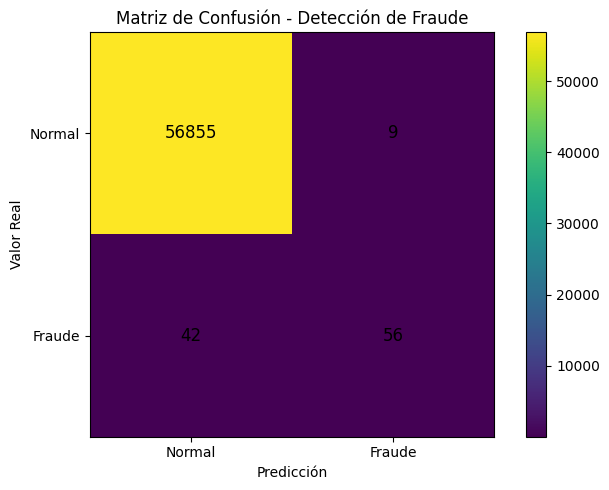

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ========================================
# MATRIZ DE CONFUSIÓN VISUAL
# ========================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(cm)

plt.colorbar(im)

ax.set_title("Matriz de Confusión - Detección de Fraude")

ax.set_xlabel("Predicción")
ax.set_ylabel("Valor Real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Normal", "Fraude"])
ax.set_yticklabels(["Normal", "Fraude"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()